## Import all the Dependencies

In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

## Set all the Constants

In [5]:
BATCH_SIZE = 16
IMAGE_SIZE = 128
CHANNELS=3
EPOCHS=25

## Import data into tensorflow dataset object

In [8]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "train",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 46356 files belonging to 25 classes.


In [10]:
class_names = dataset.class_names
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [12]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(16, 128, 128, 3)
[24 23  1 17 10 23 13 21 21 17 11 11  1 15  9 12]


## Visualize some of the images from our dataset

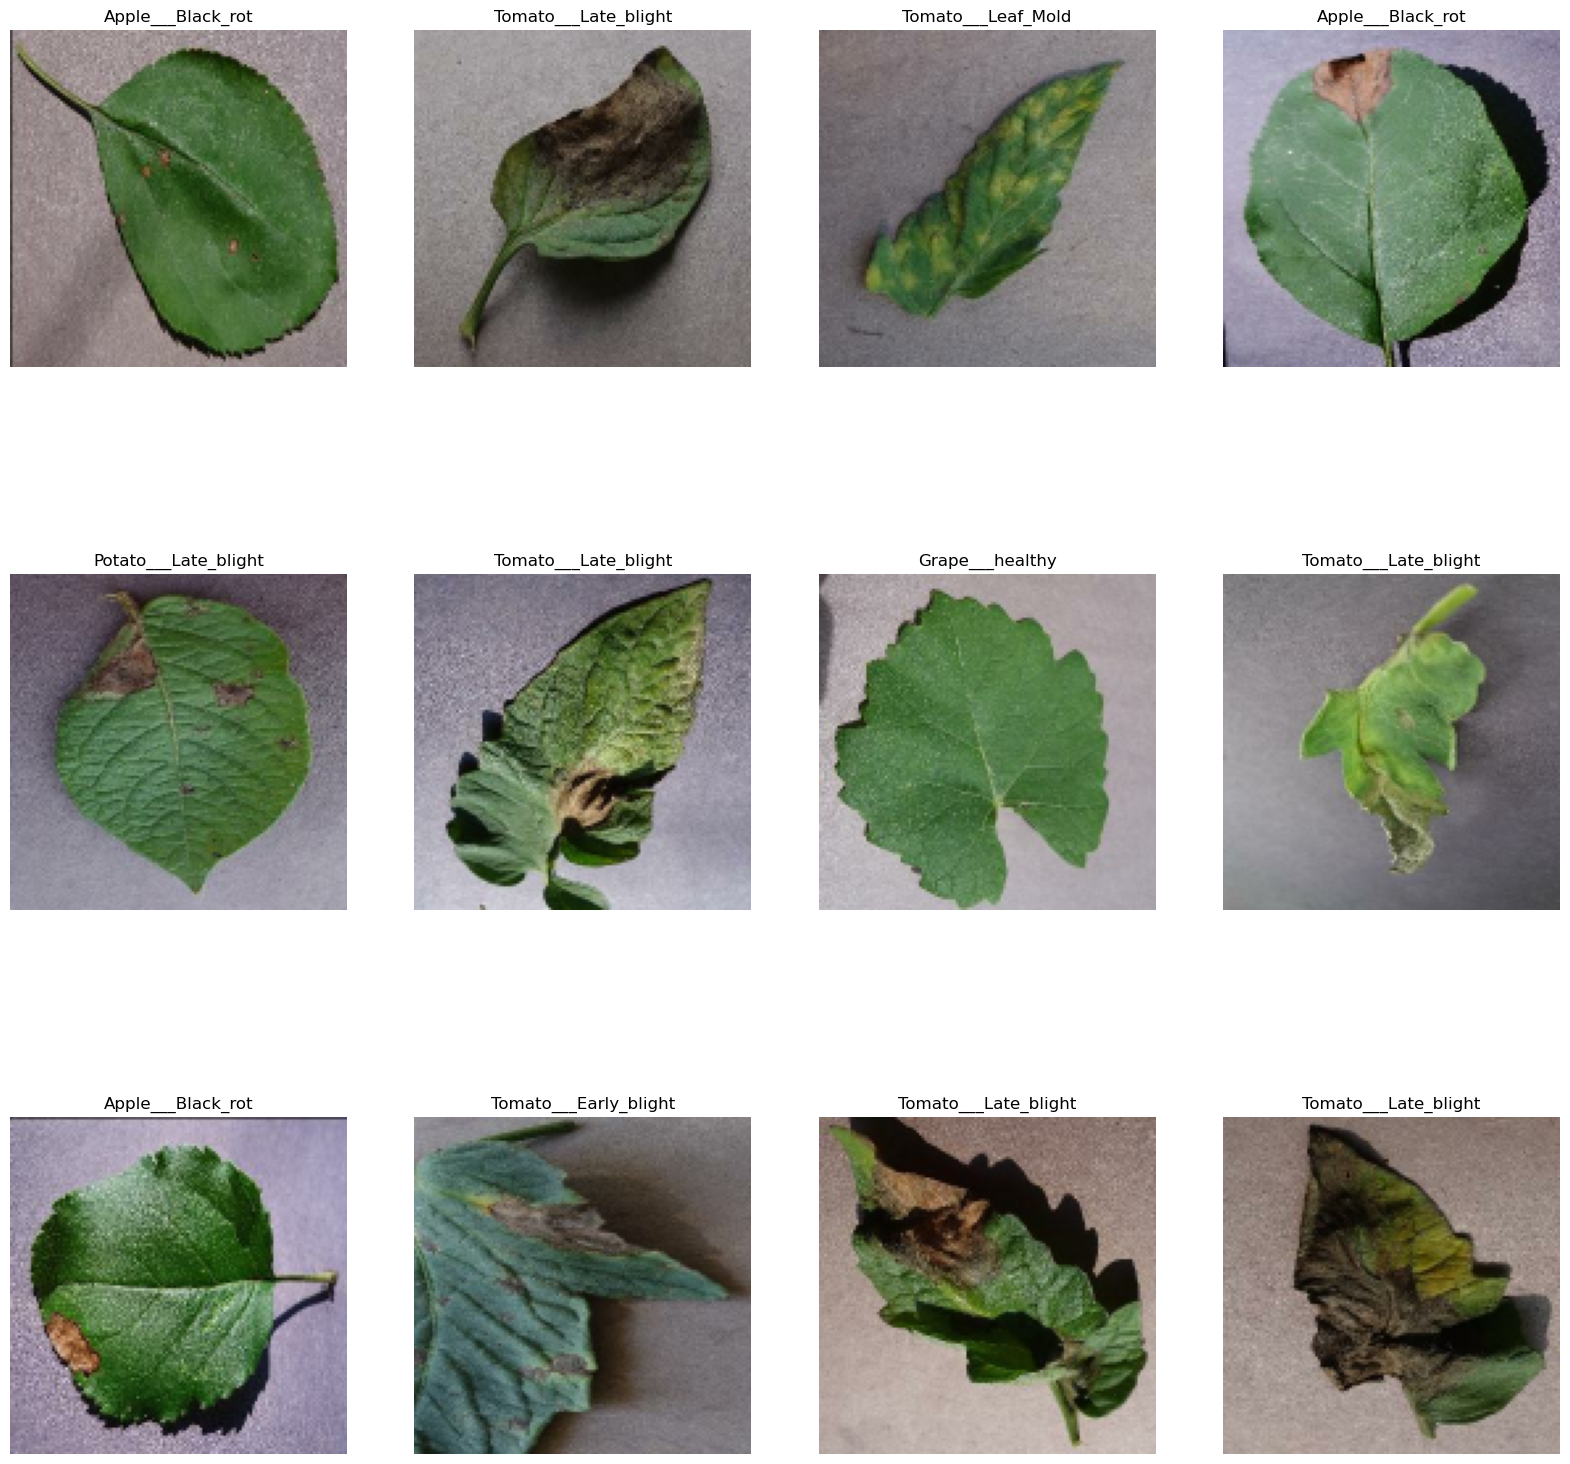

In [15]:
plt.figure(figsize=(20, 20))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [17]:
len(dataset)

2898

In [19]:
#80%==>training
#20==>10%validation, 10%test
train_size = 0.8
len(dataset)*train_size

2318.4

In [21]:
train_ds = dataset.take(2318)
len(train_ds)

2318

In [23]:
test_ds = dataset.skip(2318)
len(test_ds)

580

In [25]:
val_size=0.1
len(dataset)*val_size

289.8

In [27]:
val_ds = test_ds.take(289)
len(val_ds)

289

In [29]:
test_ds = test_ds.skip(289)
len(test_ds)

291

In [31]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=123)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [33]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [35]:
len(train_ds)

2318

In [37]:
len(val_ds)

289

In [39]:
len(test_ds)

291

## Cache, Shuffle, and Prefetch the Dataset

In [42]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Building the Model

## Creating a Layer for Resizing and Normalization

In [46]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.experimental.preprocessing.Rescaling(1./255),
])

## Data Augmentation

In [49]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
])

In [51]:
#Applying Data Augmentation to Train Dataset
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

## Model Architecture

In [54]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 25

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [56]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (16, 128, 128, 3)         0         
_________________________________________________________________
conv2d (Conv2D)              (16, 126, 126, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (16, 63, 63, 32)          0         
_________________________________________________________________
conv2d_1 (Conv2D)            (16, 61, 61, 64)          18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (16, 30, 30, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (16, 28, 28, 64)          36928     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (16, 14, 14, 64)         

## Compiling the Model

In [59]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [61]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=25,
)

Epoch 1/25
2318/2318 [==============================] - 539s 217ms/step - loss: 1.5846 - accuracy: 0.4976 - val_loss: 0.8239 - val_accuracy: 0.7340
Epoch 2/25
2318/2318 [==============================] - 546s 236ms/step - loss: 0.7024 - accuracy: 0.7697 - val_loss: 0.6340 - val_accuracy: 0.7833
Epoch 3/25
2318/2318 [==============================] - 557s 240ms/step - loss: 0.5020 - accuracy: 0.8299 - val_loss: 0.5395 - val_accuracy: 0.8227
Epoch 4/25
2318/2318 [==============================] - 562s 242ms/step - loss: 0.3893 - accuracy: 0.8671 - val_loss: 0.3522 - val_accuracy: 0.8737
Epoch 5/25
2318/2318 [==============================] - 563s 243ms/step - loss: 0.3239 - accuracy: 0.8905 - val_loss: 0.2659 - val_accuracy: 0.9074
Epoch 6/25
2318/2318 [==============================] - 565s 244ms/step - loss: 0.2845 - accuracy: 0.9048 - val_loss: 0.2918 - val_accuracy: 0.9035
Epoch 7/25
2318/2318 [==============================] - 668s 288ms/step - loss: 0.2524 - accuracy: 0.9154 - val_

In [63]:
scores = model.evaluate(test_ds)

291/291 [==============================] - 52s 58ms/step - loss: 0.1275 - accuracy: 0.9579


In [65]:
scores

[0.12746521830558777, 0.9579038023948669]

## Plotting the Accuracy and Loss Curves

In [68]:
history

In [70]:
history.params

{'verbose': 1, 'epochs': 25, 'steps': 2318}

In [72]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [74]:
type(history.history['accuracy'])

list

In [76]:
len(history.history['accuracy'])

25

In [78]:
type(history.history['loss'])

list

In [80]:
len(history.history['loss'])

25

In [82]:
history.history['accuracy']

[0.49762648344039917,
 0.7696892619132996,
 0.8299169540405273,
 0.8671107888221741,
 0.8905491232872009,
 0.9047901630401611,
 0.9153630137443542,
 0.9219710826873779,
 0.9276890754699707,
 0.9299816489219666,
 0.9358075261116028,
 0.9408512115478516,
 0.9439529776573181,
 0.9434135556221008,
 0.9471895694732666,
 0.9491584897041321,
 0.9486730098724365,
 0.9525299668312073,
 0.9523411393165588,
 0.9544179439544678,
 0.9565756916999817,
 0.9547955393791199,
 0.9566835761070251,
 0.95652174949646,
 0.9574927091598511]

In [84]:
history.history['loss'][:5] # show loss for first 5 epochs

[1.5845751762390137,
 0.7024227976799011,
 0.5020048022270203,
 0.3892974257469177,
 0.3238639831542969]

In [86]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

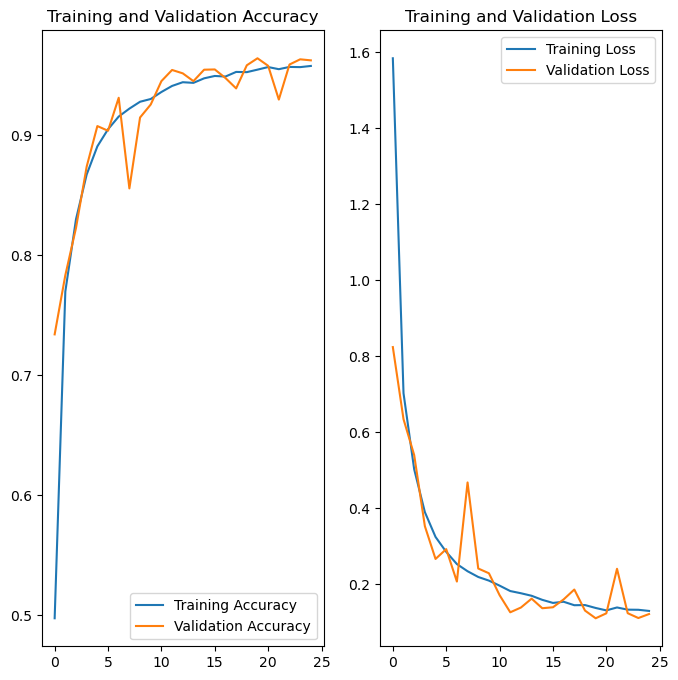

In [88]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Run prediction on a sample image

first image to predict
actual label: Apple___Black_rot
predicted label: Apple___Black_rot


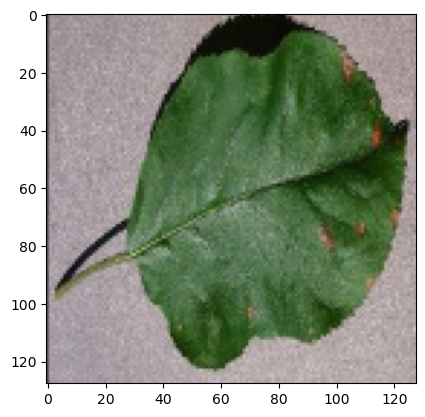

In [91]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

## Write a function for inference

In [94]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

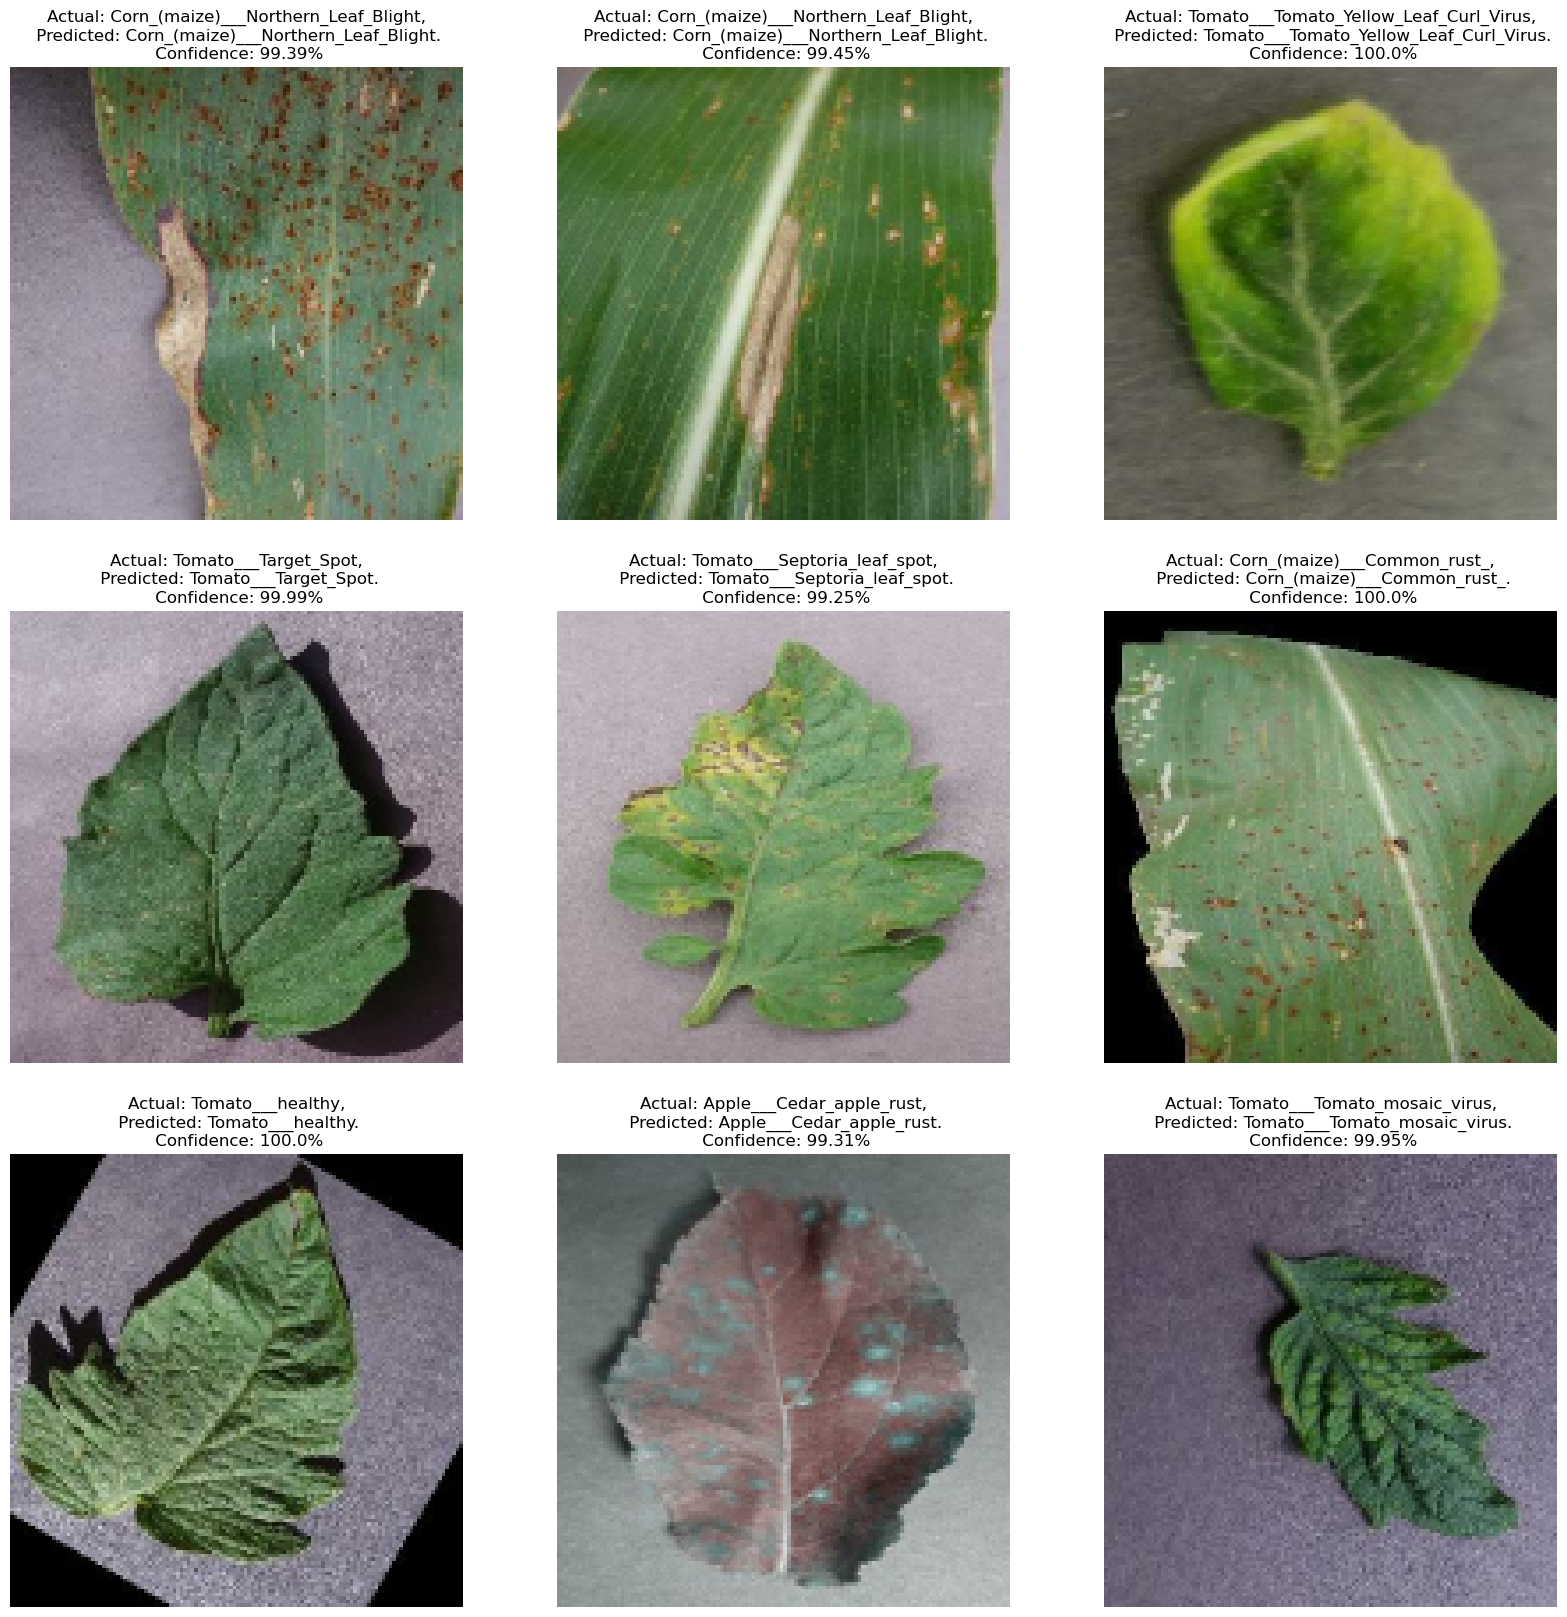

In [96]:
plt.figure(figsize=(20, 20))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

## Saving the Model

In [103]:
import os
model_version=max([int(i) for i in os.listdir("../saved_models") + [0]])+1
model.save(f"../saved_models/{model_version}")

INFO:tensorflow:Assets written to: ../saved_models/3\assets


In [105]:
model.save("../plants.h5")